<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import matplotlib.pyplot as plt



In [20]:
df = pd.read_csv("kbc177_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,llnl_hiop,00388d11e29a799a7040f9badf4fdc4de8593032,nychiang <sorakid507@gmail.com>,1741641986,add submodule smt\n,2025-03
1,llnl_hiop,005874b4049b38c61c8b191f89480a97ff31a53e,Nai-Yuan Chiang <chiang7@llnl.gov>,1636764538,"Revert ""Sparse kernel development for GPU. Par...",2021-11
2,llnl_hiop,006328732ff895df4754edca52d6dbcd2450f11f,Cosmin G. Petra <petra1@llnl.gov>,1674685053,header instrumentation for cuda vector class\n,2023-01
3,llnl_hiop,0087f3fd5a37277f284c64a5fe00bbfe0adf2a79,Jorge Alejandro Chumbipuma <chumbipuma1@lassen...,1753222477,Debugging config: Set mem_space to 'um' for un...,2025-07
4,llnl_hiop,00927223c3a65eee4cfa099925f4b0f42b43d225,Asher Mancinelli <ashermancinelli@gmail.com>,1622579363,Fix buildsystem and RAJA policies regarding HIP\n,2021-06


In [39]:
prj='brian-team_brian2genn'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


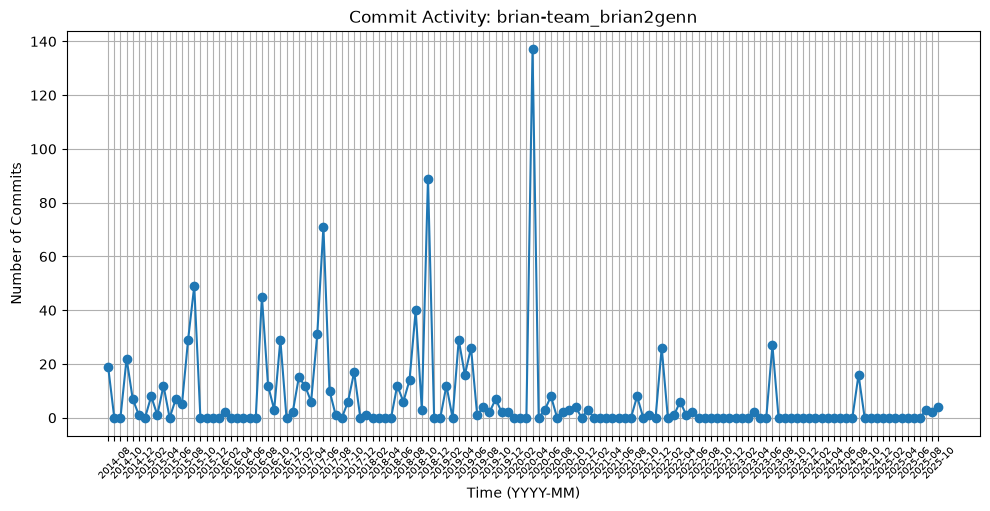

In [40]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("kbc177_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv